# Deep EDA — Electricity Load Diagrams 2011-2014

Comprehensive exploratory data analysis for PatchTST modeling.

**Dataset**: UCI ElectricityLoadDiagrams20112014 — 370 clients, 15-min intervals, 4 years

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

## 1.1 Data Loading & Validation

In [2]:
df = pd.read_csv(
    "dataset/LD2011_2014.txt",
    delimiter=";",
    decimal=",",
    parse_dates=[0],
    index_col=0,
    low_memory=False,
)
df.index.name = "Time"

print(f"Shape: {df.shape}  (expected ~140256 x 370)")
print(f"Time range: {df.index.min()} to {df.index.max()}")
print(f"Frequency (first 5 diffs):")
print(pd.Series(df.index).diff().dropna().value_counts().head())
print(f"Any NaN: {df.isna().any().any()}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: (140256, 370)  (expected ~140256 x 370)
Time range: 2011-01-01 00:15:00 to 2015-01-01 00:00:00
Frequency (first 5 diffs):
Time
0 days 00:15:00    140255
Name: count, dtype: int64
Any NaN: False
Memory: 416.3 MB


## 1.2 Client Activity Analysis

Identify which clients are active from day 1 vs late starters.

In [3]:
first_active = {}
for col in df.columns:
    nz = df[col][df[col] > 0]
    first_active[col] = nz.index[0] if len(nz) > 0 else pd.NaT

first_active_s = pd.Series(first_active).sort_values()
always_active = first_active_s[first_active_s <= df.index[0] + pd.Timedelta(days=1)]
late_starters = first_active_s[(first_active_s > df.index[0] + pd.Timedelta(days=1)) & first_active_s.notna()]
never_active = first_active_s[first_active_s.isna()]

print(f"Always active (from day 1): {len(always_active)}")
print(f"Late starters:              {len(late_starters)}")
print(f"Never active (all zeros):   {len(never_active)}")

Always active (from day 1): 158
Late starters:              212
Never active (all zeros):   0


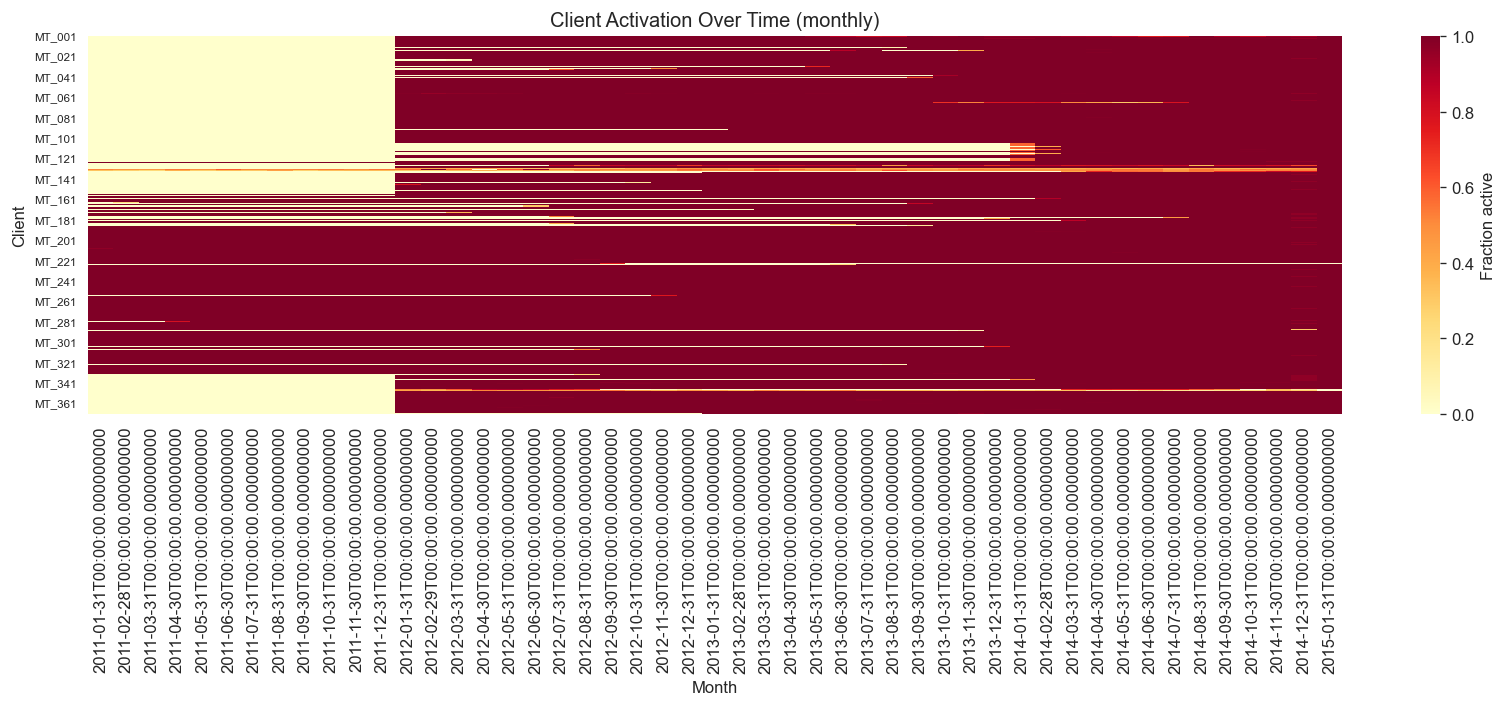

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
monthly = (df > 0).astype(int).resample("ME").mean()
sns.heatmap(monthly.T, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Fraction active"})
ax.set_title("Client Activation Over Time (monthly)")
ax.set_xlabel("Month"); ax.set_ylabel("Client")
ytick_step = 20
ax.set_yticks(range(0, len(df.columns), ytick_step))
ax.set_yticklabels([df.columns[i] for i in range(0, len(df.columns), ytick_step)], fontsize=7)
plt.tight_layout(); plt.show()

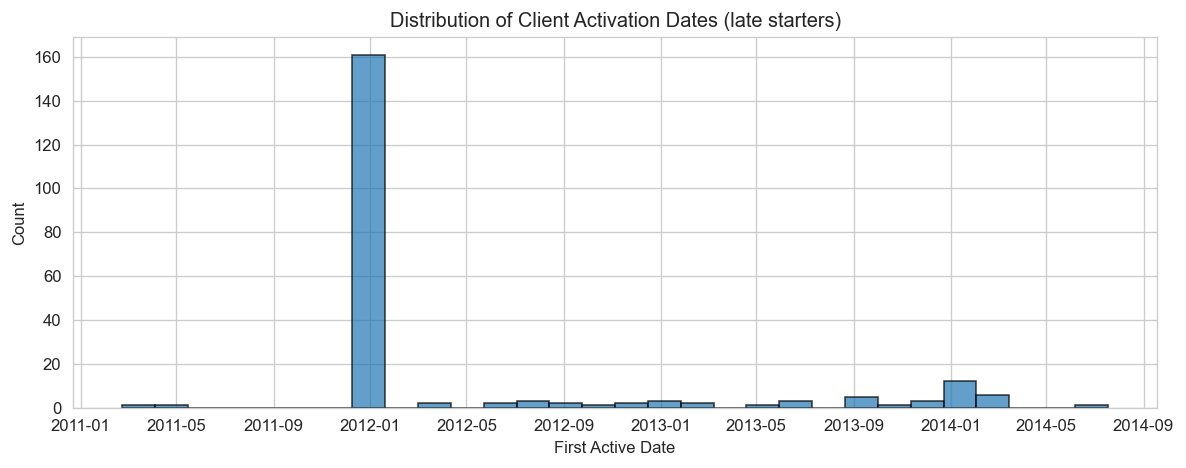

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
dates_valid = late_starters.dropna()
if len(dates_valid) > 0:
    ax.hist(dates_valid, bins=30, edgecolor="black", alpha=0.7)
    ax.set_title("Distribution of Client Activation Dates (late starters)")
    ax.set_xlabel("First Active Date"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

In [6]:
good_clients = list(always_active.index)
totals = df[good_clients].sum().sort_values(ascending=False)
top_clients = list(totals.head(10).index)
print(f"Selected {len(top_clients)} top clients: {top_clients}")

Selected 10 top clients: ['MT_196', 'MT_279', 'MT_208', 'MT_228', 'MT_220', 'MT_194', 'MT_241', 'MT_163', 'MT_216', 'MT_276']


## 1.3 Zero Value Analysis

In [7]:
zero_frac = (df == 0).mean()
print("Zero fraction stats across all clients:")
print(f"  min: {zero_frac.min():.4f}, median: {zero_frac.median():.4f}, mean: {zero_frac.mean():.4f}, max: {zero_frac.max():.4f}")
print()
for c in top_clients[:5]:
    zf = (df[c] == 0).mean()
    print(f"  {c}: {zf:.4f} ({(df[c] == 0).sum()} zero readings)")

Zero fraction stats across all clients:
  min: 0.0000, median: 0.2499, mean: 0.2015, max: 0.8864

  MT_196: 0.0002 (22 zero readings)
  MT_279: 0.0007 (96 zero readings)
  MT_208: 0.0002 (22 zero readings)
  MT_228: 0.0001 (12 zero readings)
  MT_220: 0.0001 (15 zero readings)


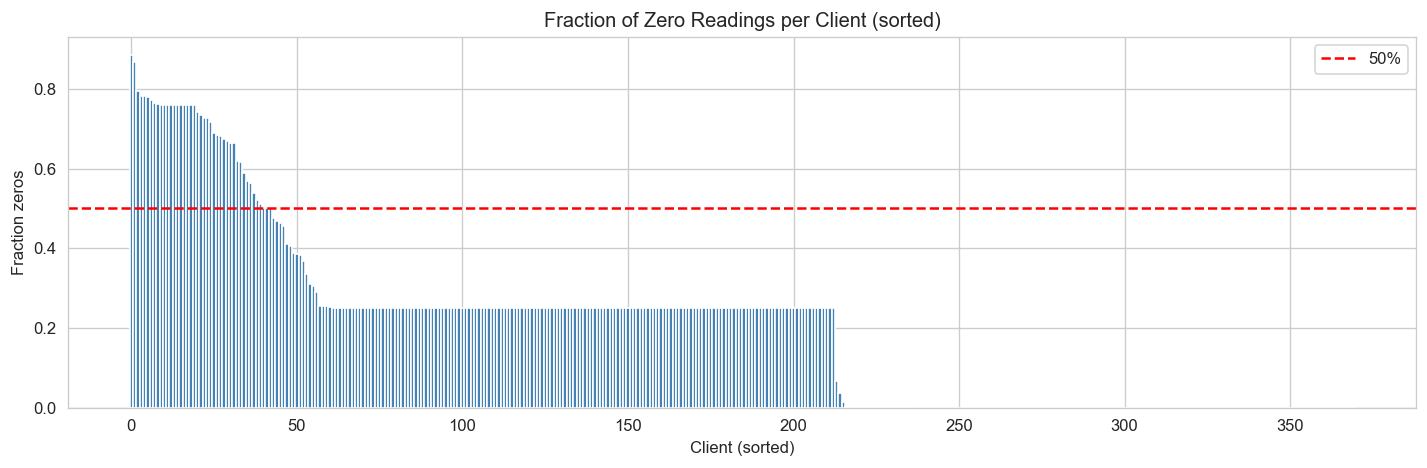

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(zero_frac.sort_values(ascending=False))),
       zero_frac.sort_values(ascending=False).values, width=1.0, color="steelblue")
ax.set_title("Fraction of Zero Readings per Client (sorted)")
ax.set_xlabel("Client (sorted)"); ax.set_ylabel("Fraction zeros")
ax.axhline(0.5, color="red", ls="--", label="50%"); ax.legend()
plt.tight_layout(); plt.show()

## 1.4 Temporal Pattern Analysis

Representative client: MT_196
  Mean: 20744.15, Std: 7339.11, Min: 0.00, Max: 78541.67


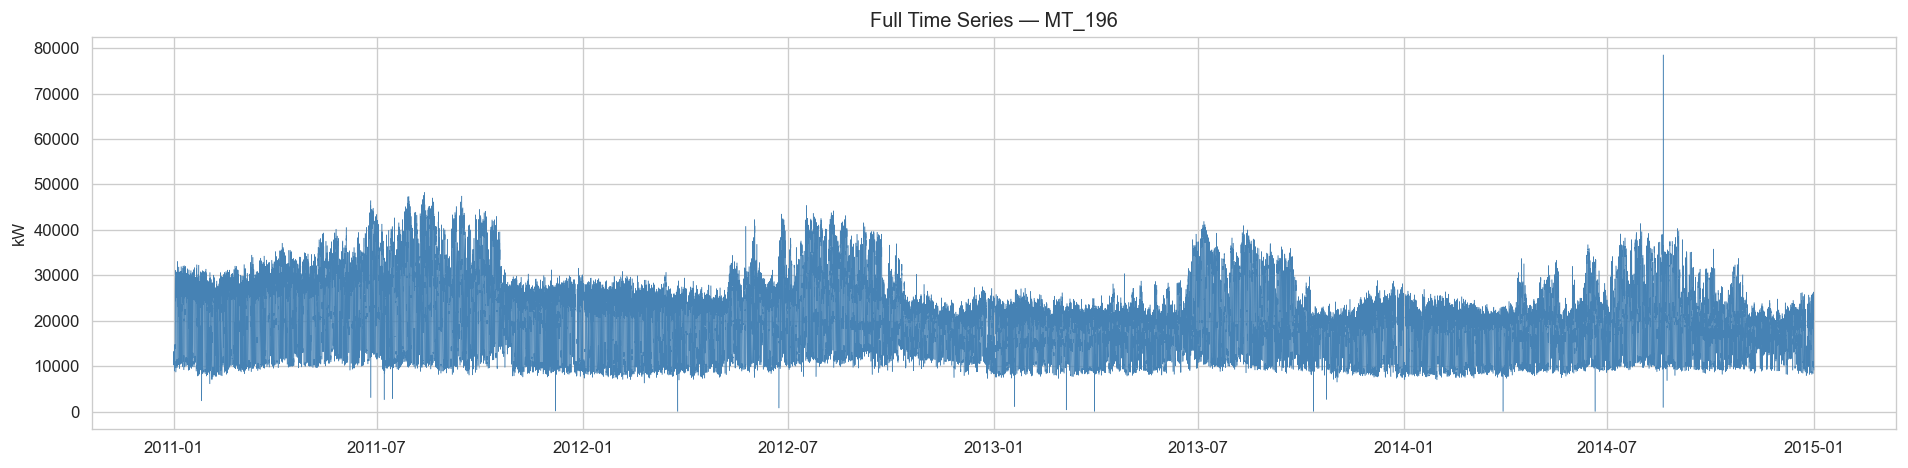

In [9]:
rep_client = top_clients[0]
ts = df[rep_client].copy()
print(f"Representative client: {rep_client}")
print(f"  Mean: {ts.mean():.2f}, Std: {ts.std():.2f}, Min: {ts.min():.2f}, Max: {ts.max():.2f}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(ts.index, ts.values, linewidth=0.3, color="steelblue")
ax.set_title(f"Full Time Series — {rep_client}"); ax.set_ylabel("kW")
plt.tight_layout(); plt.show()

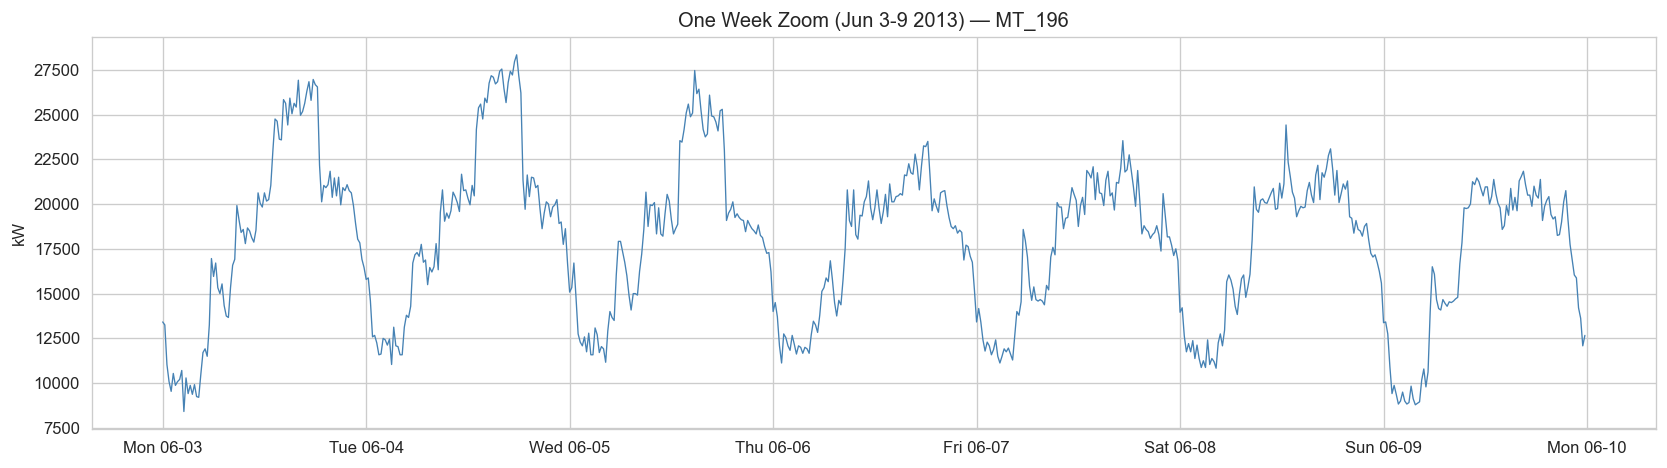

In [10]:
one_week = ts["2013-06-03":"2013-06-09"]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one_week.index, one_week.values, linewidth=0.8, color="steelblue")
ax.set_title(f"One Week Zoom (Jun 3-9 2013) — {rep_client}"); ax.set_ylabel("kW")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %m-%d"))
plt.tight_layout(); plt.show()

### Weekday vs Weekend Profile — Key Signal for Classification

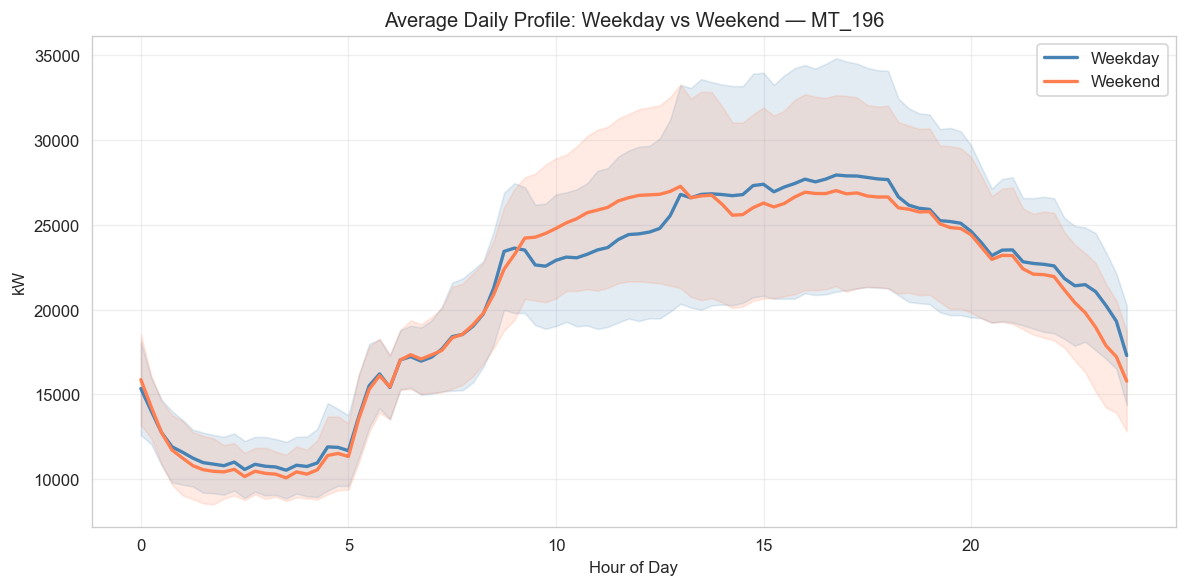

In [11]:
ts_df = ts.to_frame("consumption")
ts_df["hour"] = ts_df.index.hour + ts_df.index.minute / 60
ts_df["is_weekend"] = ts_df.index.dayofweek >= 5
ts_df["day_type"] = ts_df["is_weekend"].map({True: "Weekend", False: "Weekday"})

fig, ax = plt.subplots(figsize=(10, 5))
for dt, color in [("Weekday", "steelblue"), ("Weekend", "coral")]:
    subset = ts_df[ts_df["day_type"] == dt]
    profile = subset.groupby("hour")["consumption"].agg(["mean", "std"])
    ax.plot(profile.index, profile["mean"], label=dt, color=color, linewidth=2)
    ax.fill_between(profile.index, profile["mean"] - profile["std"],
                    profile["mean"] + profile["std"], alpha=0.15, color=color)
ax.set_title(f"Average Daily Profile: Weekday vs Weekend — {rep_client}")
ax.set_xlabel("Hour of Day"); ax.set_ylabel("kW"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

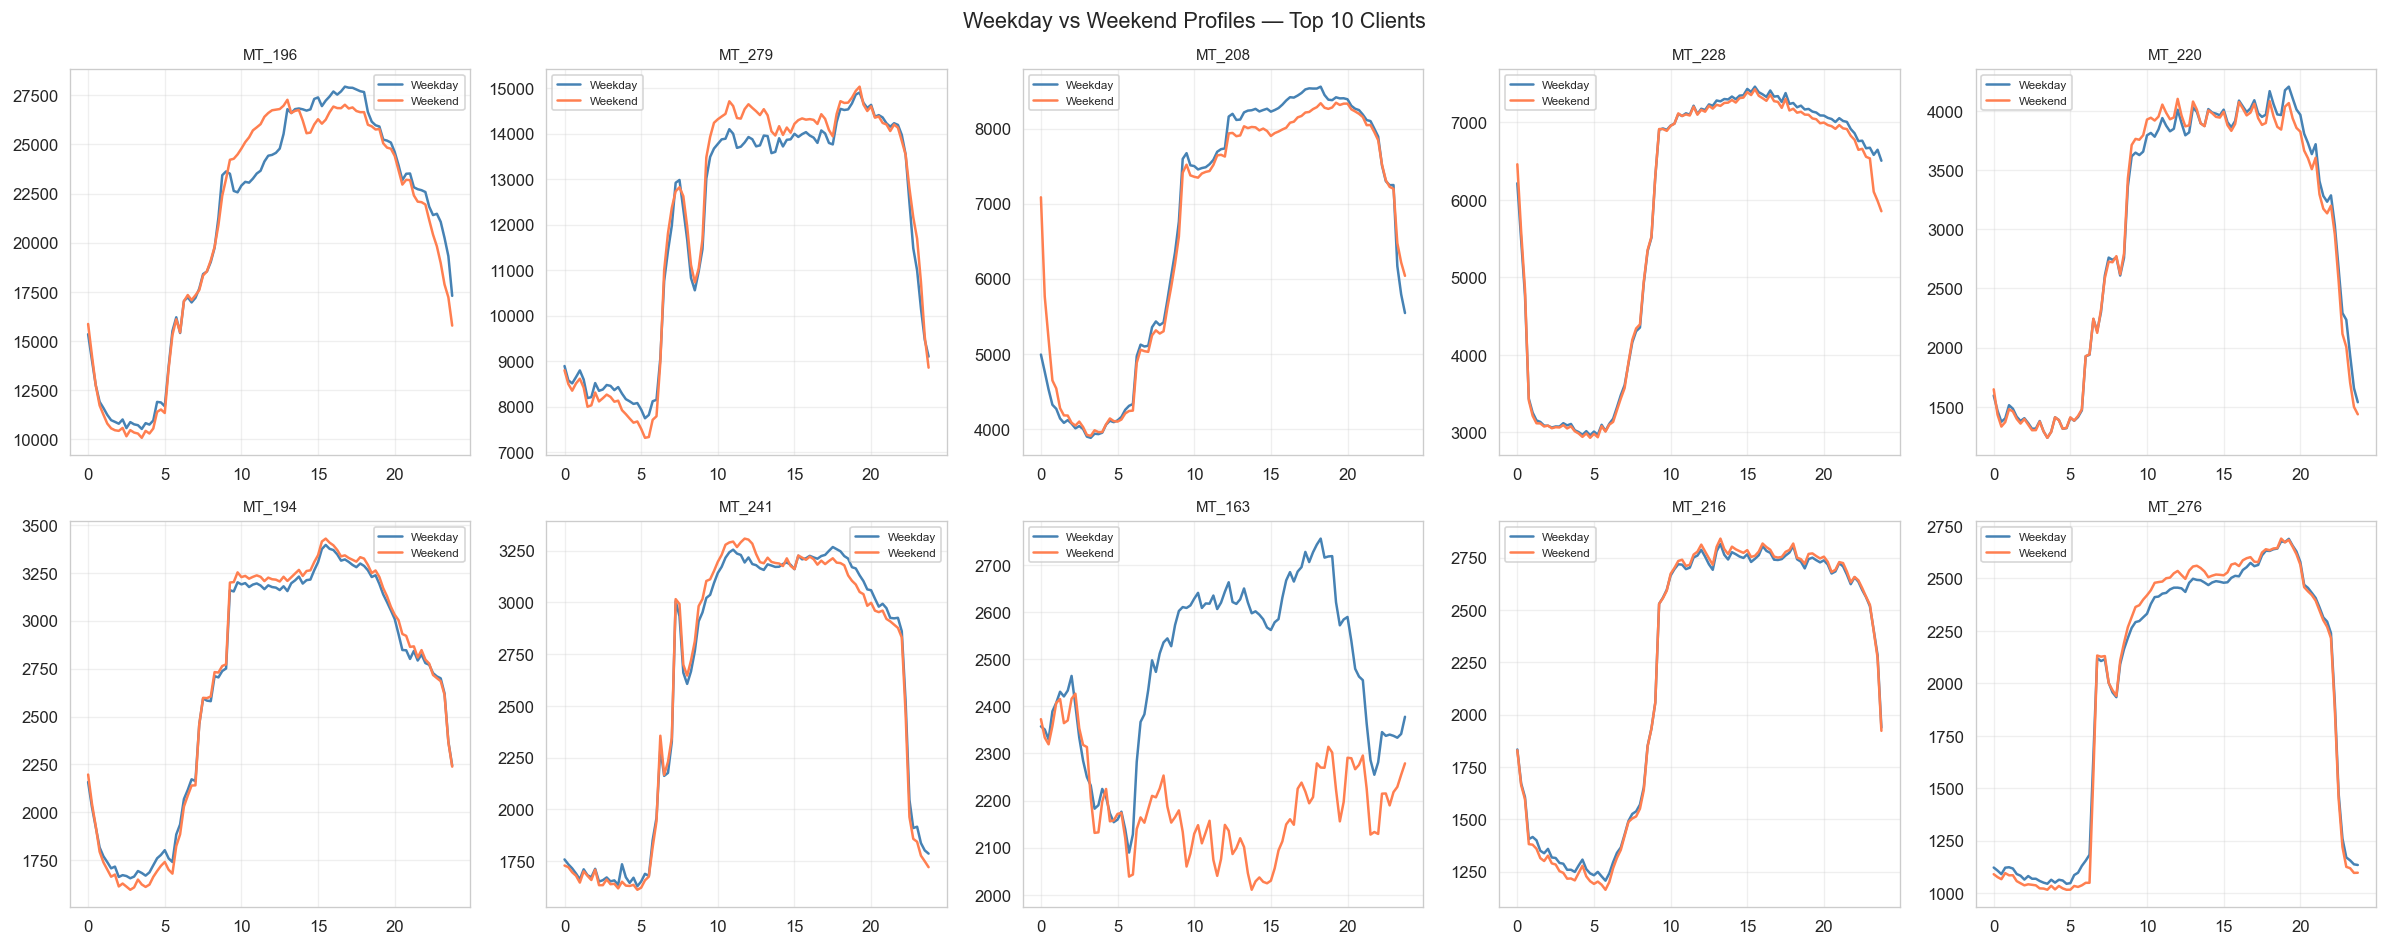

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, c in enumerate(top_clients[:10]):
    ax = axes[i]
    c_df = df[c].to_frame("consumption")
    c_df["hour"] = c_df.index.hour + c_df.index.minute / 60
    c_df["is_weekend"] = c_df.index.dayofweek >= 5
    for is_we, label, color in [(False, "Weekday", "steelblue"), (True, "Weekend", "coral")]:
        sub = c_df[c_df["is_weekend"] == is_we]
        profile = sub.groupby("hour")["consumption"].mean()
        ax.plot(profile.index, profile.values, label=label, color=color, linewidth=1.5)
    ax.set_title(c, fontsize=9); ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle("Weekday vs Weekend Profiles — Top 10 Clients", fontsize=13)
plt.tight_layout(); plt.show()

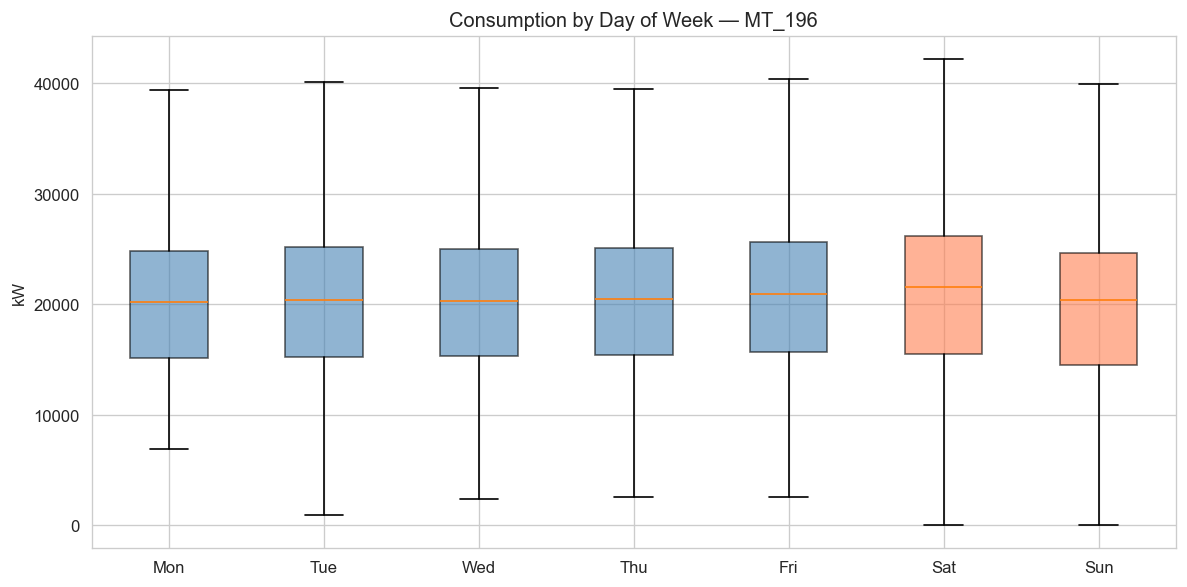

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ts_df["dow"] = ts_df.index.dayofweek
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
box_data = [ts_df[ts_df["dow"] == d]["consumption"].values for d in range(7)]
bp = ax.boxplot(box_data, tick_labels=dow_labels, showfliers=False, patch_artist=True)
colors = ["steelblue"] * 5 + ["coral"] * 2
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_title(f"Consumption by Day of Week — {rep_client}"); ax.set_ylabel("kW")
plt.tight_layout(); plt.show()

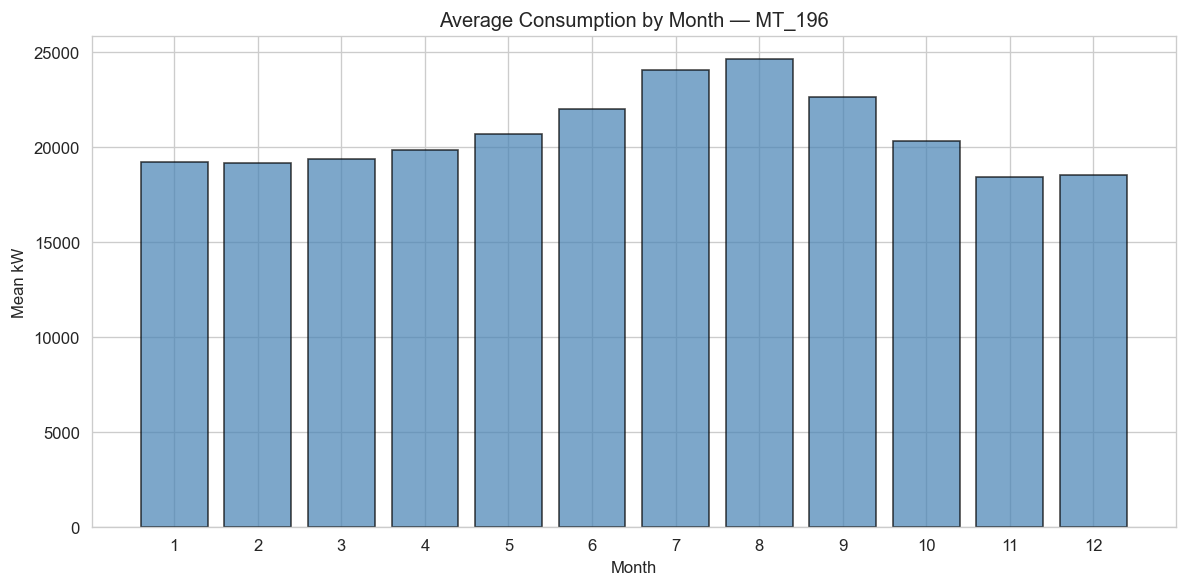

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ts_df["month"] = ts_df.index.month
monthly_avg = ts_df.groupby("month")["consumption"].mean()
ax.bar(monthly_avg.index, monthly_avg.values, color="steelblue", edgecolor="black", alpha=0.7)
ax.set_title(f"Average Consumption by Month — {rep_client}")
ax.set_xlabel("Month"); ax.set_ylabel("Mean kW"); ax.set_xticks(range(1, 13))
plt.tight_layout(); plt.show()

### Seasonal Decomposition

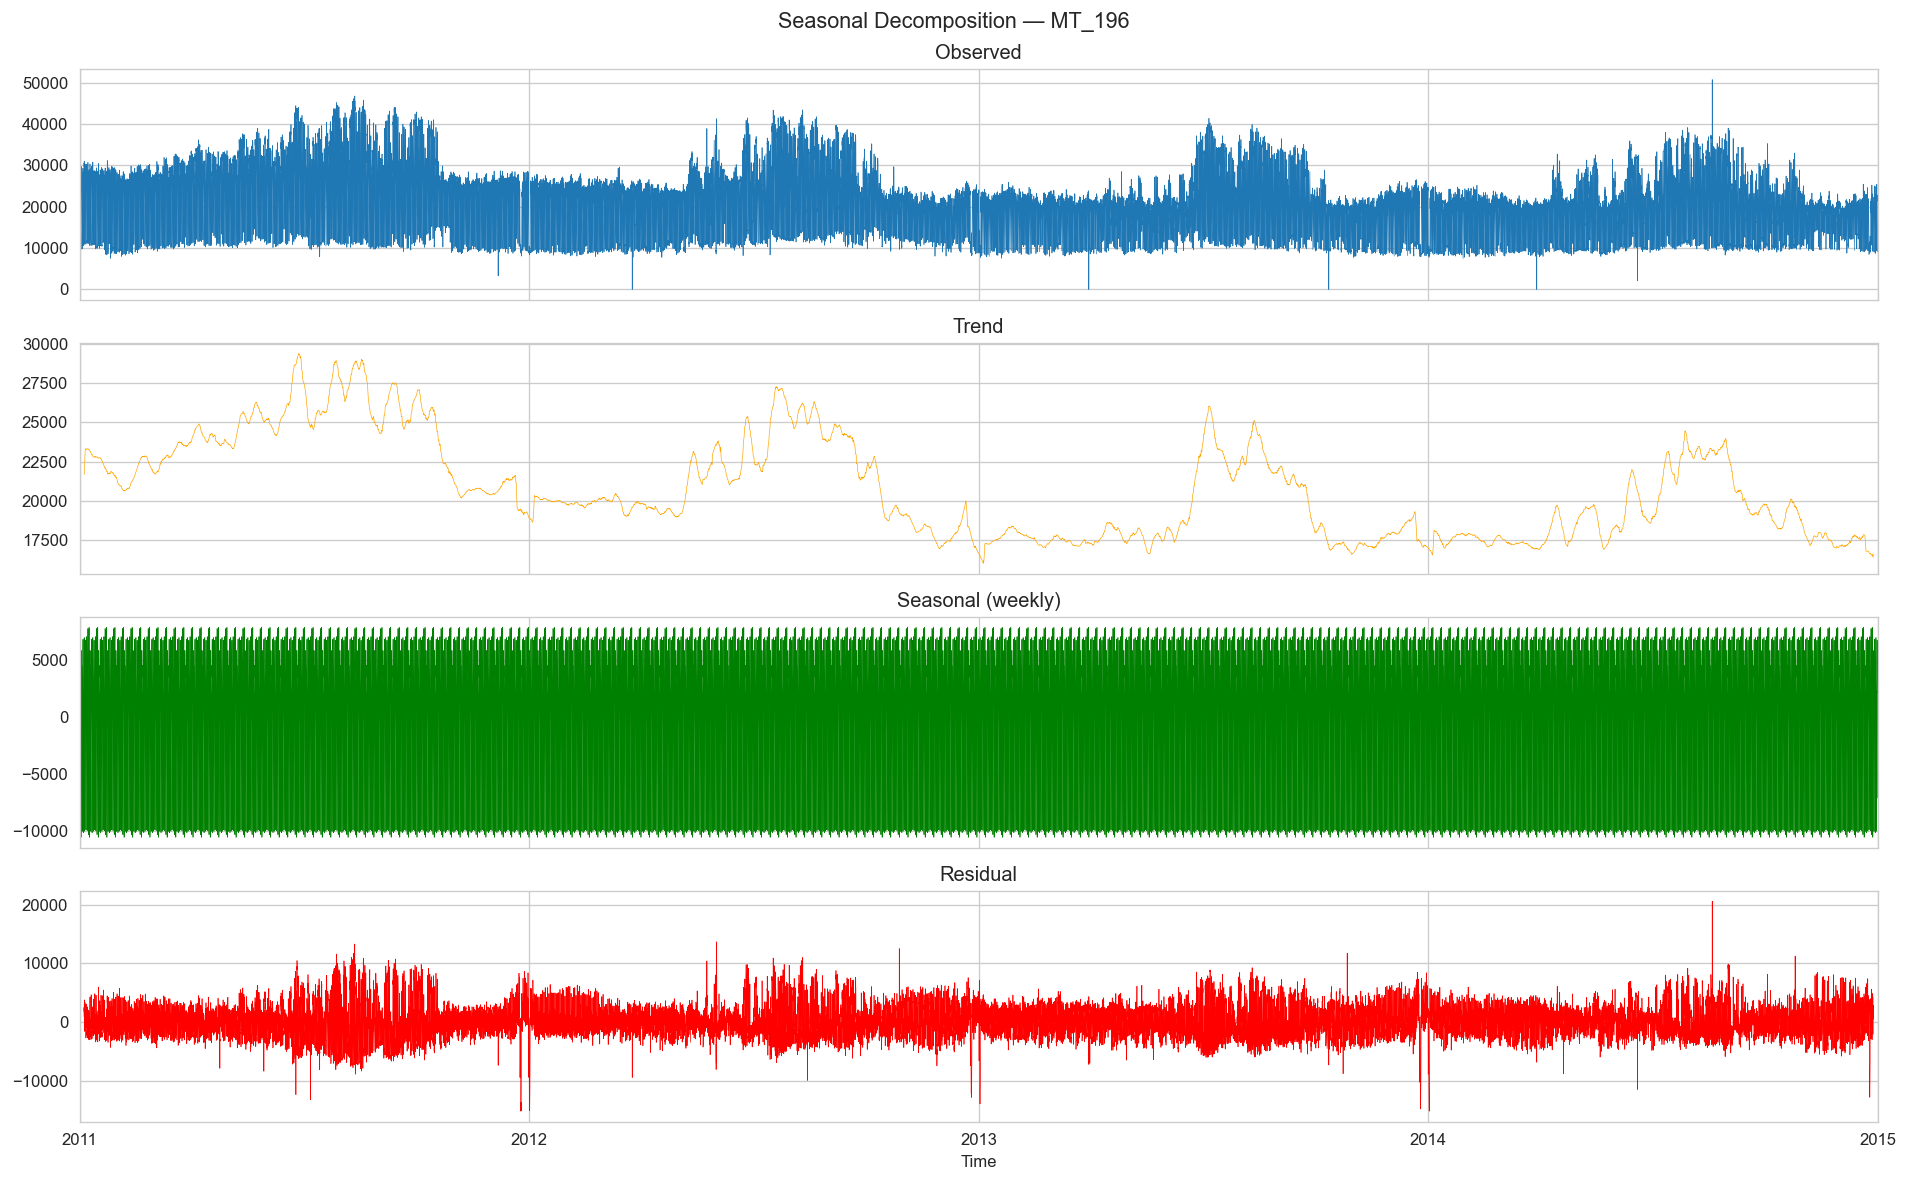

In [15]:
ts_hourly = ts.resample("h").mean()
decomp = seasonal_decompose(ts_hourly.dropna(), model="additive", period=24*7)
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
decomp.observed.plot(ax=axes[0], linewidth=0.4); axes[0].set_title("Observed")
decomp.trend.plot(ax=axes[1], linewidth=0.4, color="orange"); axes[1].set_title("Trend")
decomp.seasonal.plot(ax=axes[2], linewidth=0.4, color="green"); axes[2].set_title("Seasonal (weekly)")
decomp.resid.plot(ax=axes[3], linewidth=0.4, color="red"); axes[3].set_title("Residual")
fig.suptitle(f"Seasonal Decomposition — {rep_client}", fontsize=13)
plt.tight_layout(); plt.show()

## 1.5 Distribution Analysis

Stats for 158 always-active clients:
  Mean range: 13.60 - 20744.15



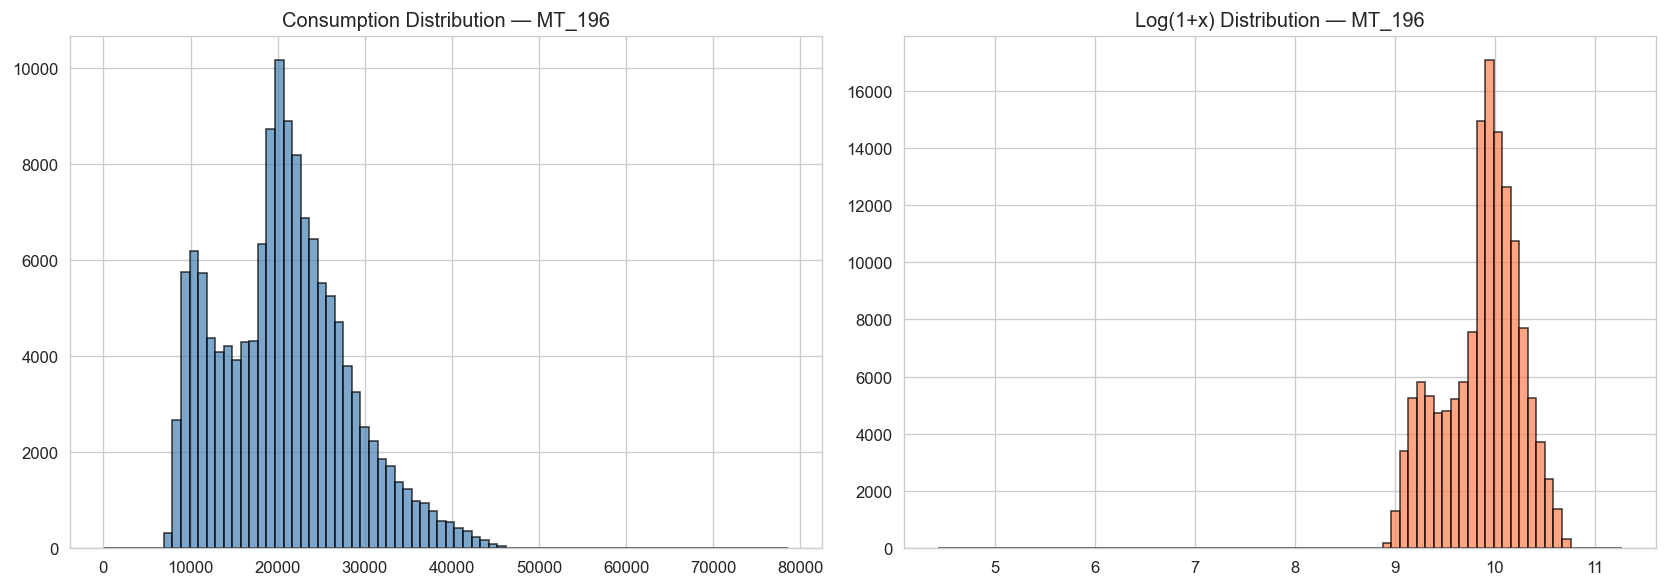

In [16]:
good_df = df[good_clients]
stats = good_df.describe().T
print(f"Stats for {len(good_clients)} always-active clients:")
print(f"  Mean range: {stats[chr(109)+chr(101)+chr(97)+chr(110)].min():.2f} - {stats[chr(109)+chr(101)+chr(97)+chr(110)].max():.2f}")
print()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nz_vals = ts[ts > 0].values
axes[0].hist(nz_vals, bins=80, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_title(f"Consumption Distribution — {rep_client}")
axes[1].hist(np.log1p(nz_vals), bins=80, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_title(f"Log(1+x) Distribution — {rep_client}")
plt.tight_layout(); plt.show()

In [17]:
Q1, Q3 = ts.quantile(0.25), ts.quantile(0.75)
IQR_val = Q3 - Q1
outliers = ts[(ts < Q1 - 1.5*IQR_val) | (ts > Q3 + 1.5*IQR_val)]
print(f"Outlier analysis (IQR) for {rep_client}:")
print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR_val:.2f}")
print(f"  Bounds: [{Q1-1.5*IQR_val:.2f}, {Q3+1.5*IQR_val:.2f}]")
print(f"  Outliers: {len(outliers)} ({100*len(outliers)/len(ts):.2f}%)")
print()
print("DST edge cases:")
for year in [2011, 2012, 2013, 2014]:
    march_dates = pd.date_range(f"{year}-03-25", f"{year}-03-31", freq="15min")
    march_data = ts.reindex(march_dates)
    march_zeros = march_data[march_data == 0]
    if len(march_zeros) > 0:
        print(f"  {year} March: {len(march_zeros)} zeros around DST transition")

Outlier analysis (IQR) for MT_196:
  Q1=15208.33, Q3=25208.33, IQR=10000.00
  Bounds: [208.33, 40208.33]
  Outliers: 1399 (1.00%)

DST edge cases:
  2012 March: 4 zeros around DST transition
  2014 March: 4 zeros around DST transition


### Stationarity Tests — All Always-Active Clients

Running both **ADF** (H0: unit root / non-stationary) and **KPSS** (H0: stationary) tests on all always-active clients (hourly resampled).

- ADF stationary if p < 0.05
- KPSS stationary if p >= 0.05

In [18]:
from statsmodels.tsa.stattools import kpss
import warnings
warnings.filterwarnings("ignore")

results = []
print(f"Running ADF + KPSS on {len(good_clients)} clients (hourly)...")
for idx, c in enumerate(good_clients):
    ts_h = df[c].resample("h").mean().dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(ts_h, autolag="AIC", maxlag=48)
    kpss_stat, kpss_p, _, _ = kpss(ts_h, regression="c", nlags="auto")
    results.append({
        "client": c, "adf_stat": adf_stat, "adf_p": adf_p,
        "adf_stationary": adf_p < 0.05,
        "kpss_stat": kpss_stat, "kpss_p": kpss_p,
        "kpss_stationary": kpss_p >= 0.05,
    })
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx+1}/{len(good_clients)}")

stat_df = pd.DataFrame(results)
print(f"Done. {len(stat_df)} clients tested.")

Running ADF + KPSS on 158 clients (hourly)...


  Processed 50/158


  Processed 100/158


  Processed 150/158


Done. 158 clients tested.


In [19]:
adf_stat_count = stat_df["adf_stationary"].sum()
kpss_stat_count = stat_df["kpss_stationary"].sum()
both = ((stat_df["adf_stationary"]) & (stat_df["kpss_stationary"])).sum()
neither = ((~stat_df["adf_stationary"]) & (~stat_df["kpss_stationary"])).sum()
adf_only = ((stat_df["adf_stationary"]) & (~stat_df["kpss_stationary"])).sum()
kpss_only = ((~stat_df["adf_stationary"]) & (stat_df["kpss_stationary"])).sum()

print("=== Stationarity Summary (all always-active clients) ===")
print(f"  ADF stationary:  {adf_stat_count}/{len(stat_df)}")
print(f"  KPSS stationary: {kpss_stat_count}/{len(stat_df)}")
print(f"  Both stationary:     {both}")
print(f"  Both non-stationary: {neither}")
print(f"  ADF only stationary: {adf_only}")
print(f"  KPSS only stationary: {kpss_only}")
print()
print("ADF p-value stats:")
print(stat_df["adf_p"].describe())
print()
print("KPSS p-value stats:")
print(stat_df["kpss_p"].describe())

=== Stationarity Summary (all always-active clients) ===
  ADF stationary:  156/158
  KPSS stationary: 0/158
  Both stationary:     0
  Both non-stationary: 2
  ADF only stationary: 156
  KPSS only stationary: 0

ADF p-value stats:
count    1.580000e+02
mean     7.000803e-03
std      5.980693e-02
min      0.000000e+00
25%      4.133895e-14
50%      9.612433e-10
75%      8.337628e-08
max      6.574285e-01
Name: adf_p, dtype: float64

KPSS p-value stats:
count    158.000000
mean       0.010082
std        0.001031
min        0.010000
25%        0.010000
50%        0.010000
75%        0.010000
max        0.022962
Name: kpss_p, dtype: float64


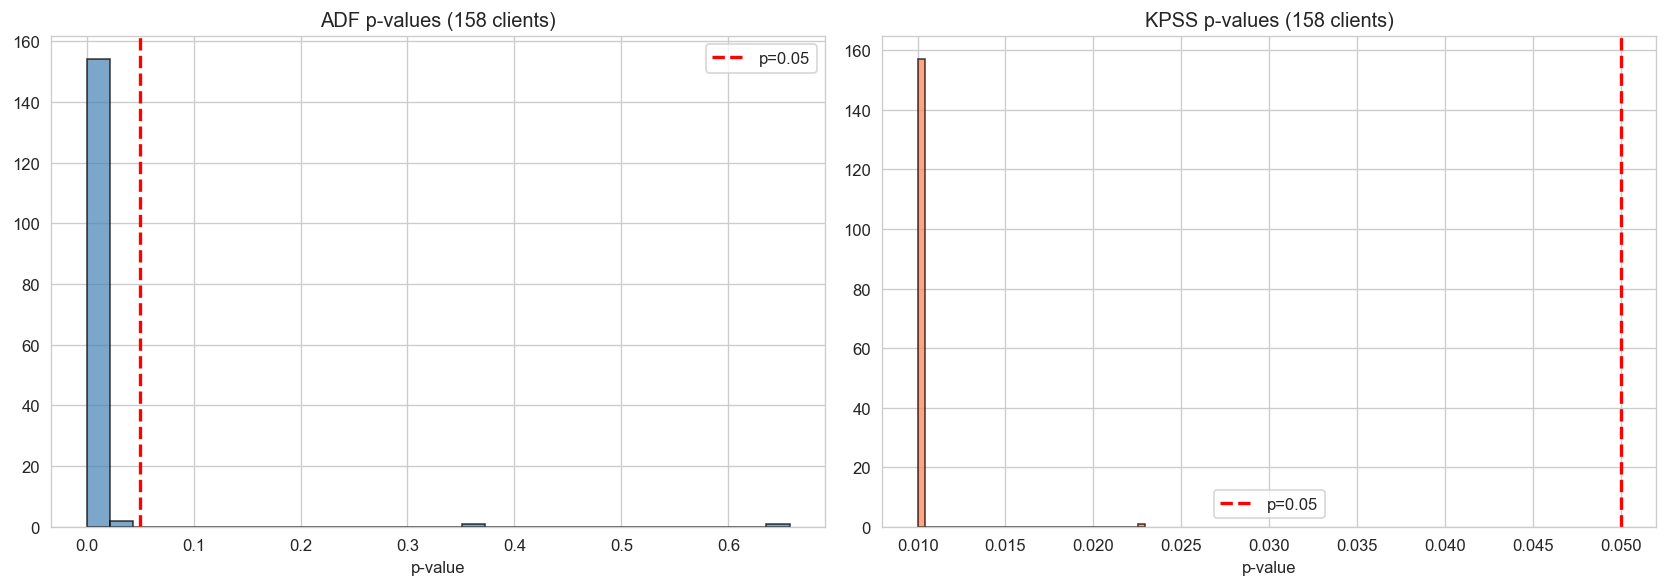

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(stat_df["adf_p"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(0.05, color="red", ls="--", linewidth=2, label="p=0.05")
axes[0].set_title(f"ADF p-values ({len(good_clients)} clients)")
axes[0].set_xlabel("p-value"); axes[0].legend()
axes[1].hist(stat_df["kpss_p"], bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[1].axvline(0.05, color="red", ls="--", linewidth=2, label="p=0.05")
axes[1].set_title(f"KPSS p-values ({len(good_clients)} clients)")
axes[1].set_xlabel("p-value"); axes[1].legend()
plt.tight_layout(); plt.show()

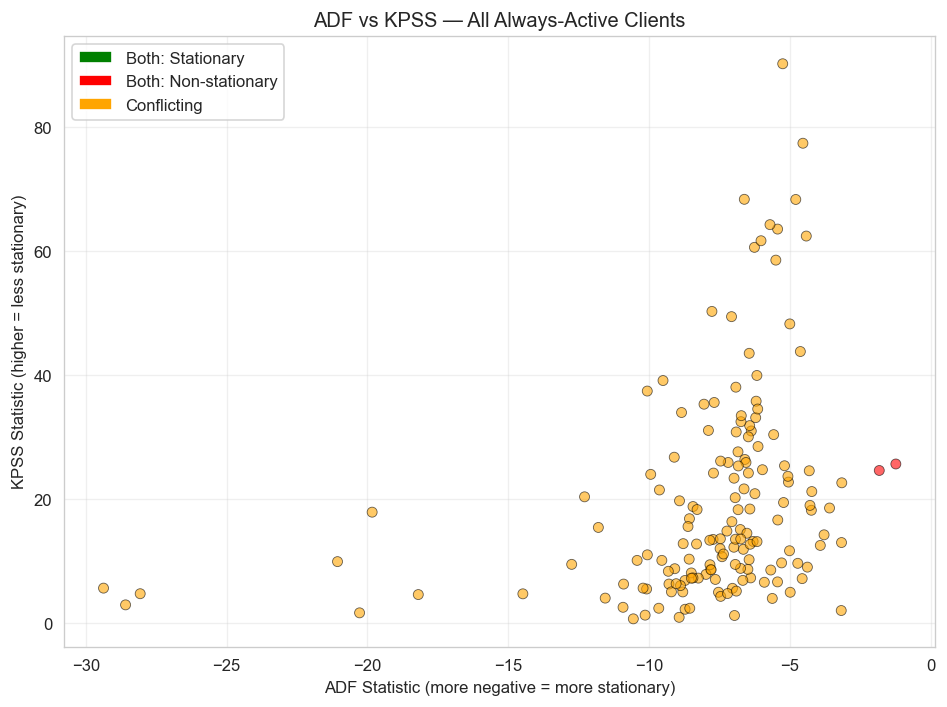

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = []
for _, row in stat_df.iterrows():
    if row["adf_stationary"] and row["kpss_stationary"]:
        colors.append("green")
    elif not row["adf_stationary"] and not row["kpss_stationary"]:
        colors.append("red")
    else:
        colors.append("orange")
ax.scatter(stat_df["adf_stat"], stat_df["kpss_stat"], c=colors, alpha=0.6, edgecolors="black", linewidth=0.5)
ax.set_xlabel("ADF Statistic (more negative = more stationary)")
ax.set_ylabel("KPSS Statistic (higher = less stationary)")
ax.set_title("ADF vs KPSS — All Always-Active Clients")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="green", label="Both: Stationary"),
    Patch(facecolor="red", label="Both: Non-stationary"),
    Patch(facecolor="orange", label="Conflicting")])
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Outlier Analysis — All Always-Active Clients

Outlier % across all always-active clients:
count    158.000000
mean       0.263293
std        0.945036
min        0.000000
25%        0.000000
50%        0.015686
75%        0.091796
max        7.208248
Name: outlier_pct, dtype: float64


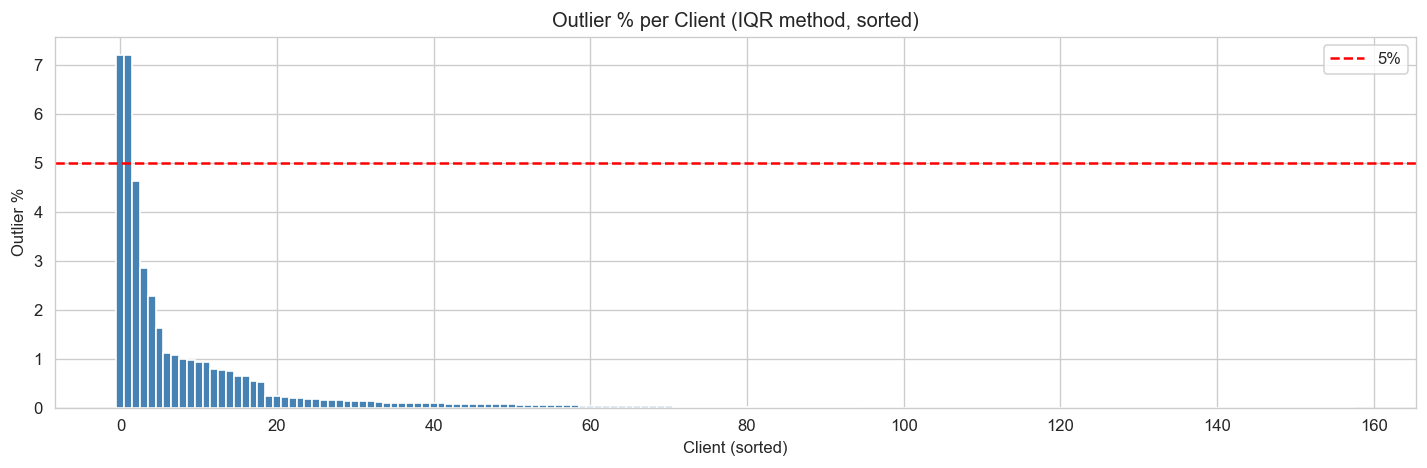

In [22]:
outlier_stats = []
for c in good_clients:
    s = df[c]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    outlier_stats.append({"client": c, "outlier_pct": 100*n_out/len(s), "mean": s.mean(), "std": s.std()})

out_df = pd.DataFrame(outlier_stats)
print("Outlier % across all always-active clients:")
print(out_df["outlier_pct"].describe())

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(out_df)), out_df["outlier_pct"].sort_values(ascending=False).values, width=1.0, color="steelblue")
ax.set_title("Outlier % per Client (IQR method, sorted)")
ax.set_xlabel("Client (sorted)"); ax.set_ylabel("Outlier %")
ax.axhline(5, color="red", ls="--", label="5%"); ax.legend()
plt.tight_layout(); plt.show()

## 1.6 Autocorrelation Analysis

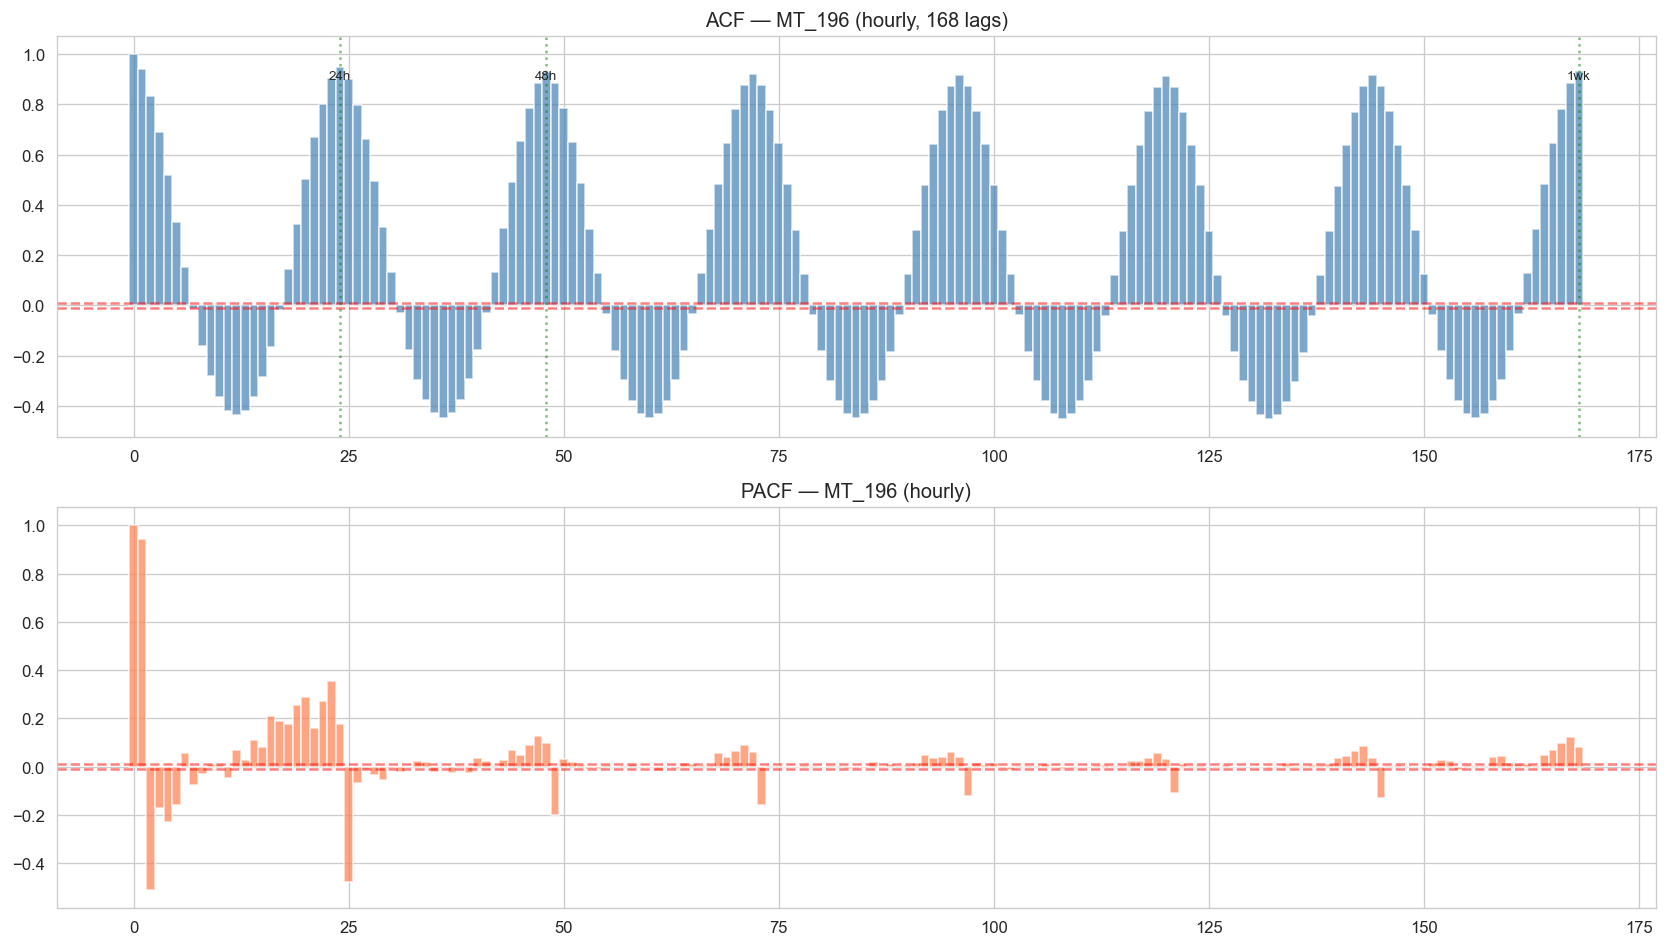

Key ACF values:
  Lag   1h (0.0d): 0.9429
  Lag   4h (0.2d): 0.5206
  Lag  24h (1.0d): 0.9495
  Lag  48h (2.0d): 0.9300
  Lag  96h (4.0d): 0.9183
  Lag 168h (7.0d): 0.9317


In [23]:
ts_h_clean = ts_hourly.dropna()
n_lags = 168
acf_vals = acf(ts_h_clean, nlags=n_lags)
pacf_vals = pacf(ts_h_clean, nlags=min(n_lags, len(ts_h_clean)//2-1))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].bar(range(len(acf_vals)), acf_vals, width=1.0, color="steelblue", alpha=0.7)
ci = 1.96 / np.sqrt(len(ts_h_clean))
axes[0].axhline(ci, ls="--", color="red", alpha=0.5)
axes[0].axhline(-ci, ls="--", color="red", alpha=0.5)
for lag, label in [(24, "24h"), (48, "48h"), (168, "1wk")]:
    if lag < len(acf_vals):
        axes[0].axvline(lag, ls=":", color="green", alpha=0.5)
        axes[0].text(lag, max(acf_vals)*0.9, label, fontsize=8, ha="center")
axes[0].set_title(f"ACF — {rep_client} (hourly, {n_lags} lags)")
axes[1].bar(range(len(pacf_vals)), pacf_vals, width=1.0, color="coral", alpha=0.7)
axes[1].axhline(ci, ls="--", color="red", alpha=0.5)
axes[1].axhline(-ci, ls="--", color="red", alpha=0.5)
axes[1].set_title(f"PACF — {rep_client} (hourly)")
plt.tight_layout(); plt.show()

print("Key ACF values:")
for lag in [1, 4, 24, 48, 96, 168]:
    if lag < len(acf_vals):
        print(f"  Lag {lag:>3}h ({lag/24:.1f}d): {acf_vals[lag]:.4f}")

## 1.7 Aggregated Load Analysis

Total load (158 clients): mean=109791.37, std=31245.27


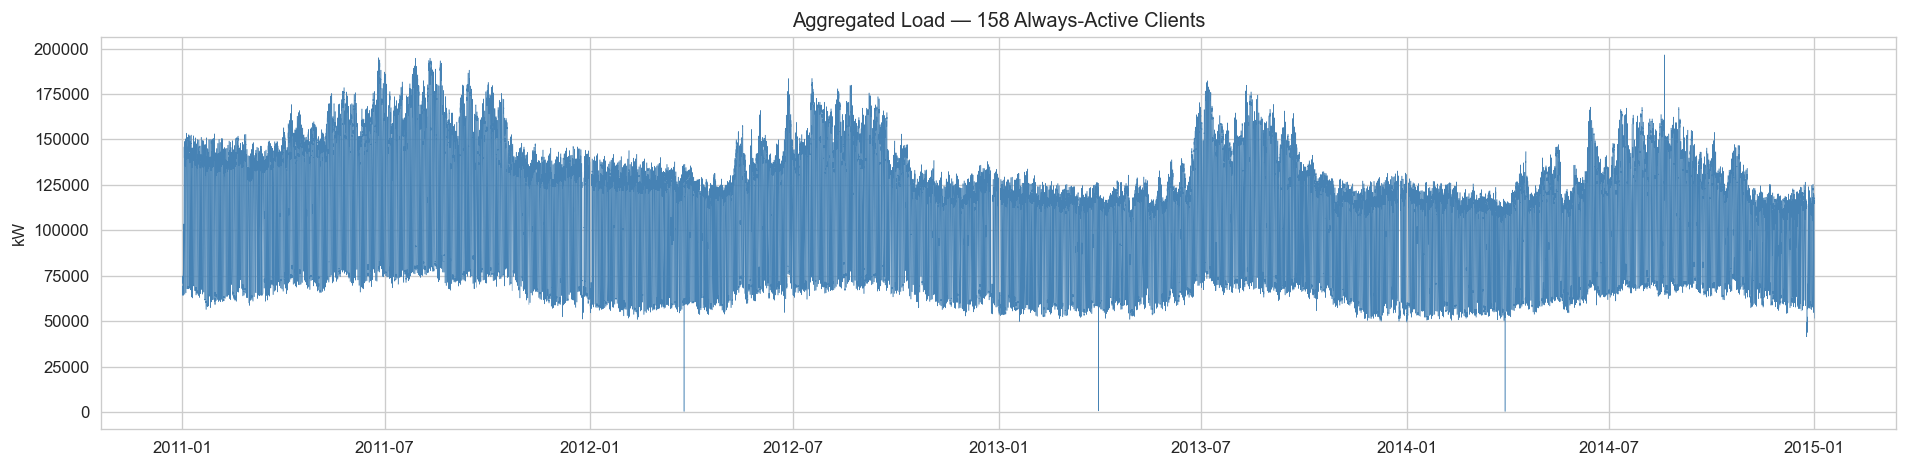

In [24]:
total_load = df[good_clients].sum(axis=1)
print(f"Total load ({len(good_clients)} clients): mean={total_load.mean():.2f}, std={total_load.std():.2f}")

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(total_load.index, total_load.values, linewidth=0.3, color="steelblue")
ax.set_title(f"Aggregated Load — {len(good_clients)} Always-Active Clients"); ax.set_ylabel("kW")
plt.tight_layout(); plt.show()

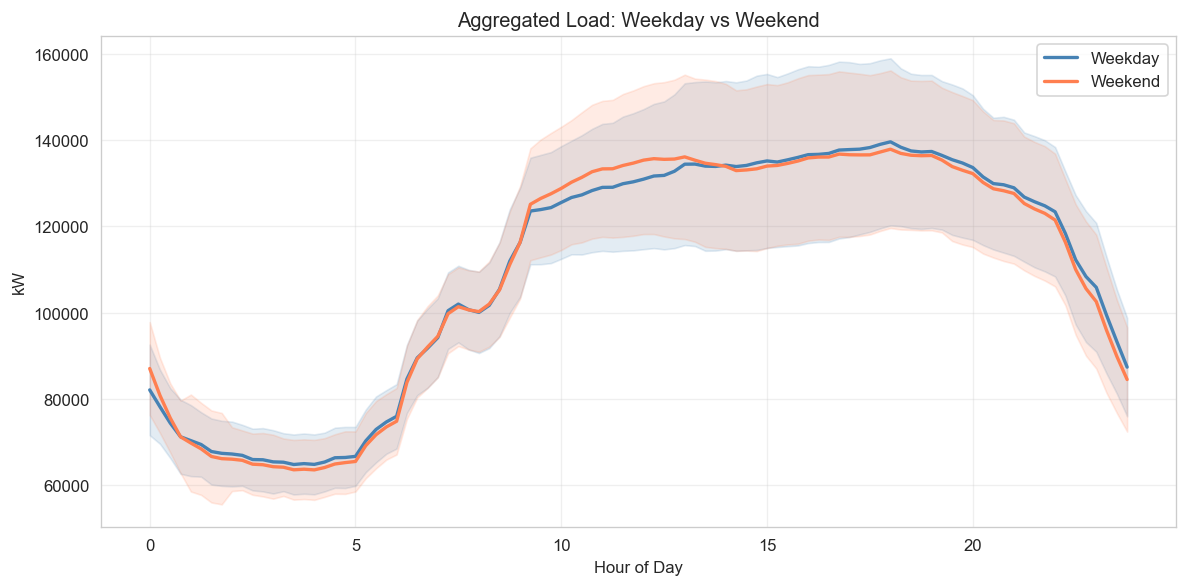

In [25]:
total_df = total_load.to_frame("total")
total_df["hour"] = total_df.index.hour + total_df.index.minute / 60
total_df["is_weekend"] = total_df.index.dayofweek >= 5

fig, ax = plt.subplots(figsize=(10, 5))
for is_we, label, color in [(False, "Weekday", "steelblue"), (True, "Weekend", "coral")]:
    sub = total_df[total_df["is_weekend"] == is_we]
    profile = sub.groupby("hour")["total"].agg(["mean", "std"])
    ax.plot(profile.index, profile["mean"], label=label, color=color, linewidth=2)
    ax.fill_between(profile.index, profile["mean"] - profile["std"],
                    profile["mean"] + profile["std"], alpha=0.15, color=color)
ax.set_title("Aggregated Load: Weekday vs Weekend")
ax.set_xlabel("Hour of Day"); ax.set_ylabel("kW"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 1.8 Cross-Client Correlation

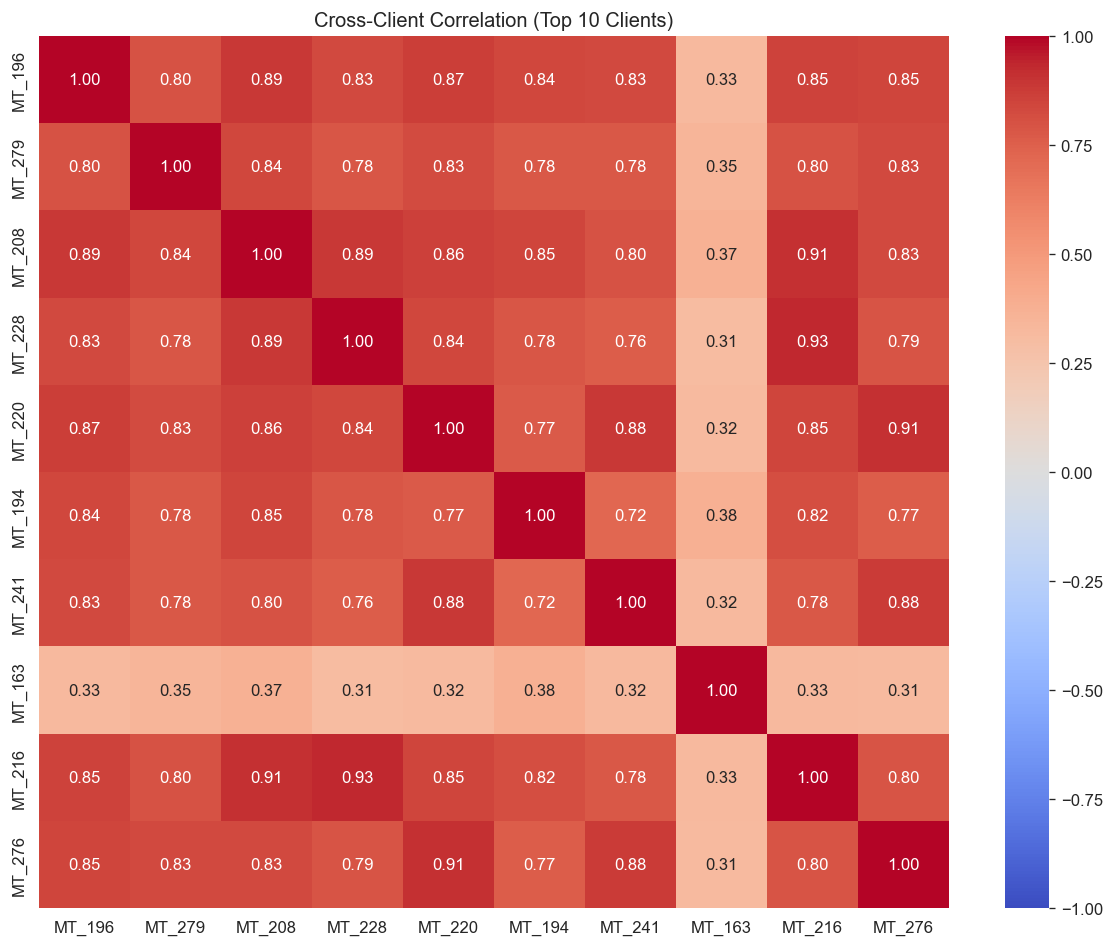

Mean pairwise correlation: 0.7295


In [26]:
corr = df[top_clients].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Cross-Client Correlation (Top 10 Clients)")
plt.tight_layout(); plt.show()
print(f"Mean pairwise correlation: {corr.values[np.triu_indices_from(corr.values, k=1)].mean():.4f}")